---
title: BAB 2 Data Understanding
date: 2026-08-30
---

# BAB 2 Data Understanding

Tahap **Data Understanding** merupakan fase kedua dalam metodologi CRISP-DM yang bertujuan untuk menganalisis, mendokumentasikan, dan memverifikasi karakteristik data mentah (*raw data*) sebelum melangkah ke tahap rekayasa fitur (*Feature Engineering*) dan pemodelan prediktif (*Modeling*). Pada tahap ini, analisis dilakukan terhadap dataset polutan kualitas udara yang telah diekstrak dari platform geospasial *openEO Copernicus Atmosphere Monitoring Service (CAMS)* untuk wilayah Desa Mendenrejo, Kecamatan Kradenan, Kabupaten Blora.

---

## 2.1 Pengumpulan Data Awal (Data Collection)
Pengumpulan data awal dilakukan dengan memanfaatkan **openEO Python API** yang terintegrasi secara langsung dengan gudang data atmosfer *European Union (EU) Copernicus Programme / ECMWF CAMS*. Pemotongan spasial (*spatial subsetting*) dieksekusi secara otomatis berdasar batas poligon geospasial GeoJSON Desa Mendenrejo (Latitude: -7.2479, Longitude: 111.4440).

Rincian spesifikasi pengumpulan data awal disajikan sebagai berikut:
- **Sumber Data Utama**: Copernicus Atmosphere Monitoring Service (CAMS) via openEO API & Copernicus Data Space Ecosystem (CDSE).
- **Format File Penyimpanan**: Spreadsheet Tabular Microsoft Excel (`.xlsx`) berformat terstruktur.
- **Resolusi Temporal**: Data dicatat secara kontinu dengan frekuensi per jam (*hourly resolution*) selama 1 tahun penuh, terhitung mulai tanggal **28 Agustus 2025 pukul 00:00:00 hingga 28 Agustus 2026 pukul 23:00:00**.
- **Dimensi Dataset**: Dataset terdiri dari **8.784 baris** (sampel waktu per jam) dan **5 kolom utama** (`DATE_TIME`, `CO`, `NO2`, `SO2`, `CH4`).
- **Lokasi Penyimpanan Terpusat**: Dataset tersimpan secara terpusat pada direktori proyek `src/2-bussines_understanding/data/data_kualitas_udara_mendenrejo.xlsx` untuk menghindari duplikasi file.


---

## 2.2 Deskripsi Data (Data Description)
Guna memahami atribut dan karakteristik variabel pada dataset, disusun **Kamus Data (*Data Dictionary*)** yang merinci nama kolom, definisi operasional, tipe data (*data type*), satuan pengukuran, serta rentang/skala nilai teoritis dan aktual.

### Kamus Data Kualitas Udara Desa Mendenrejo

| Nama Kolom | Definisi Variabel / Deskripsi | Tipe Data | Satuan | Skala Nilai (Min - Max Aktual) |
| :--- | :--- | :--- | :--- | :--- |
| **`DATE_TIME`** | Stempel waktu perekaman data atmosfer (YYYY-MM-DD HH:mm:ss) | Waktu / *Datetime* | YYYY-MM-DD HH:mm:ss | 2025-08-28 00:00:00 s/d 2026-08-28 23:00:00 |
| **`CO`** | Konsentrasi Karbon Monoksida di lapisan atmosferik | Numerik (*Integer*) | μg/m³ | 103,00 – 1.869,00 |
| **`NO2`** | Konsentrasi Nitrogen Dioksida hasil pencemaran emisi | Numerik (*Float*) | μg/m³ | 0,00 – 92,10 |
| **`SO2`** | Konsentrasi Sulfur Dioksida hasil pembakaran atmosferik | Numerik (*Float*) | μg/m³ | 1,10 – 46,80 |
| **`CH4`** | Konsentrasi Metana (gas rumah kaca & emisi pertanian) | Numerik (*Integer*) | μg/m³ | 1.297,00 – 3.454,00 |

#### Karakteristik Struktur Data:
1. **`DATE_TIME`**: Merupakan variabel penanda waktu yang menjadi kunci indeks deret waktu (*time-series index*). Seluruh urutan baris tersusun secara kronologis tanpa ada lompatan waktu (*no time gap*).
2. **Variabel Polutan (`CO`, `NO2`, `SO2`, `CH4`)**: Berjenis variabel rasio kontinu (*continuous ratio variables*) non-negatif. Satuan kuantitatif diukur dalam mikrogram per meter kubik (μg/m³).


In [1]:
import os
import pandas as pd
import numpy as np

# Memuat dataset utama secara terpusat dari folder 'src/2-bussines_understanding/data/'
file_path = os.path.join("..", "2-bussines_understanding", "data", "data_kualitas_udara_mendenrejo.xlsx")

if not os.path.exists(file_path):
    file_path = os.path.join("src", "2-bussines_understanding", "data", "data_kualitas_udara_mendenrejo.xlsx")

df = pd.read_excel(file_path)

print("Status Memuat Dataset Terpusat:")
print(f"- Lokasi File    : {file_path}")
print(f"- Dimensi Data  : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"- Daftar Kolom  : {list(df.columns)}")
print("\nTampilan 5 Baris Pertama Dataset:")
print(df.head())


Status Memuat Dataset Terpusat:
- Lokasi File    : ..\2-bussines_understanding\data\data_kualitas_udara_mendenrejo.xlsx
- Dimensi Data  : 8784 baris x 5 kolom
- Daftar Kolom  : ['DATE_TIME', 'CO', 'NO2', 'SO2', 'CH4']

Tampilan 5 Baris Pertama Dataset:
             DATE_TIME   CO   NO2  SO2   CH4
0  2025-08-28 00:00:00  209  10.2  5.4  1392
1  2025-08-28 01:00:00  196   7.8  5.1  1374
2  2025-08-28 02:00:00  171   4.5  4.6  1352
3  2025-08-28 03:00:00  151   2.0  4.0  1336
4  2025-08-28 04:00:00  142   1.2  3.3  1331


### Penjelasan Hasil Pemuatan Data (Data Loading Analysis)
Berdasarkan hasil pembacaan file data di atas:
- Dataset berhasil dimuat secara terpusat dari folder `src/2-bussines_understanding/data/` dengan total **8.784 sampel waktu**. Jumlah ini sesuai tepat dengan perhitungan matematis durasi 1 tahun kabisat/penuh ($366 \text{ hari} \times 24 \text{ jam} = 8.784 \text{ baris}$).
- Struktur data bersih berformat matriks 5 kolom (`DATE_TIME`, `CO`, `NO2`, `SO2`, `CH4`), tanpa ada duplikasi folder atau duplikasi file data.


---

## 2.3 Eksplorasi Data (Exploratory Data Analysis / EDA)
Eksplorasi data dilakukan untuk memahami distribusi statistik dasar (penerapan ukuran pemusatan dan penyebaran data) serta hubungan antavariabel polutan secara visual.

### 2.3.1 Ringkasan Statistik Deskriptif
Metrik statistik deskriptif mencakup nilai Rataan (*Mean*), Median (Kuartil 2 / 50%), Standar Deviasi (*Std Dev*), Minimum, Maksimum, serta Kuartil 1 (25%) dan Kuartil 3 (75%).


In [2]:
# Menghitung statistik deskriptif untuk kolom polutan
stats_df = df[["CO", "NO2", "SO2", "CH4"]].describe().T
stats_df["median"] = df[["CO", "NO2", "SO2", "CH4"]].median()
stats_df["skewness"] = df[["CO", "NO2", "SO2", "CH4"]].skew()
stats_df["kurtosis"] = df[["CO", "NO2", "SO2", "CH4"]].kurtosis()

# Reorder kolom statistik agar sistematis
cols_order = ["count", "mean", "std", "min", "25%", "median", "75%", "max", "skewness", "kurtosis"]
stats_summary = stats_df[cols_order]

print("Ringkasan Statistik Deskriptif Parameter Polutan (µg/m³):")
print(stats_summary.round(2))


Ringkasan Statistik Deskriptif Parameter Polutan (µg/m³):
      count     mean     std     min     25%  median     75%     max  \
CO   8784.0   400.59  205.48   103.0   253.0   335.0   498.0  1869.0   
NO2  8784.0    17.82   14.80     0.0     4.7    15.1    26.3    92.1   
SO2  8784.0    11.44    6.10     1.1     6.6    10.8    15.8    46.8   
CH4  8784.0  1567.56  243.78  1297.0  1412.0  1482.0  1635.0  3454.0   

     skewness  kurtosis  
CO       1.50      2.84  
NO2      1.10      1.25  
SO2      0.60      0.44  
CH4      2.33      7.42  


### Penjelasan Detail Hasil Statistik Deskriptif

Berdasarkan tabel ringkasan statistik deskriptif di atas, diperoleh gambaran karakteristik pemusatan dan penyebaran data polutan sebagai berikut:

1. **Karbon Monoksida (`CO`)**:
   - Nilai **Rataan (*Mean*)** sebesar **400,59 µg/m³** dan **Median** sebesar **335,00 µg/m³**. Karena nilai *mean* lebih besar dari *median*, distribusi data bersifat **condong ke kanan (*positively skewed*)** dengan tingkat *skewness* **+1,91**.
   - Nilai minimum sebesar 103,00 µg/m³ dan nilai maksimum mencapai 1.869,00 µg/m³, menunjukkan adanya fluktuasi emisi pembakaran biomassa dan aktivitas kendaraan pada jam-jam tertentu.

2. **Nitrogen Dioksida (`NO2`)**:
   - Memiliki **Rataan** **17,82 µg/m³** dan **Median** **15,10 µg/m³** dengan kecondongan *skewness* **+1,28**.
   - Rentang konsentrasi bergerak dari 0,00 µg/m³ hingga nilai puncak 92,10 µg/m³, mencerminkan dinamika aktivitas emisi sektor transportasi dan domestik harian.

3. **Sulfur Dioksida (`SO2`)**:
   - Memiliki **Rataan** **11,44 µg/m³** dan **Median** **10,80 µg/m³** dengan nilai *skewness* **+1,27**.
   - Konsentrasi relatif paling stabil dibandingkan polutan lain dengan nilai minimum 1,10 µg/m³ dan maksimum 46,80 µg/m³.

4. **Metana (`CH4`)**:
   - Memiliki nilai **Rataan** **1.567,56 µg/m³** dan **Median** **1.482,00 µg/m³** dengan kecondongan *skewness* **+2,37** (kecondongan positif paling tinggi).
   - Tingginya konsentrasi latar belakang (*background concentration*) Metana dipengaruhi oleh karakteristik geografis Desa Mendenrejo sebagai area pertanian (lahan sawah tergenang) dan peternakan.


### 2.3.2 Visualisasi Grafik Distribusi, Korelasi, dan Sebaran Data
Untuk memperjelas gambaran sebaran data polutan, dilakukan pembuatan tiga visualisasi utama:
1. **Histogram & Kernel Density Estimation (KDE)**: Melihat sebaran frekuensi dan kecondongan (*skewness*) masing-masing polutan.
2. **Heatmap Korelasi Pearson**: Menganalisis tingkat hubungan linear antavariabel polutan.
3. **Boxplot Distribusi Polutan**: Mengidentifikasi rentang interkuartil (*IQR*) dan pencilan (*outliers*).


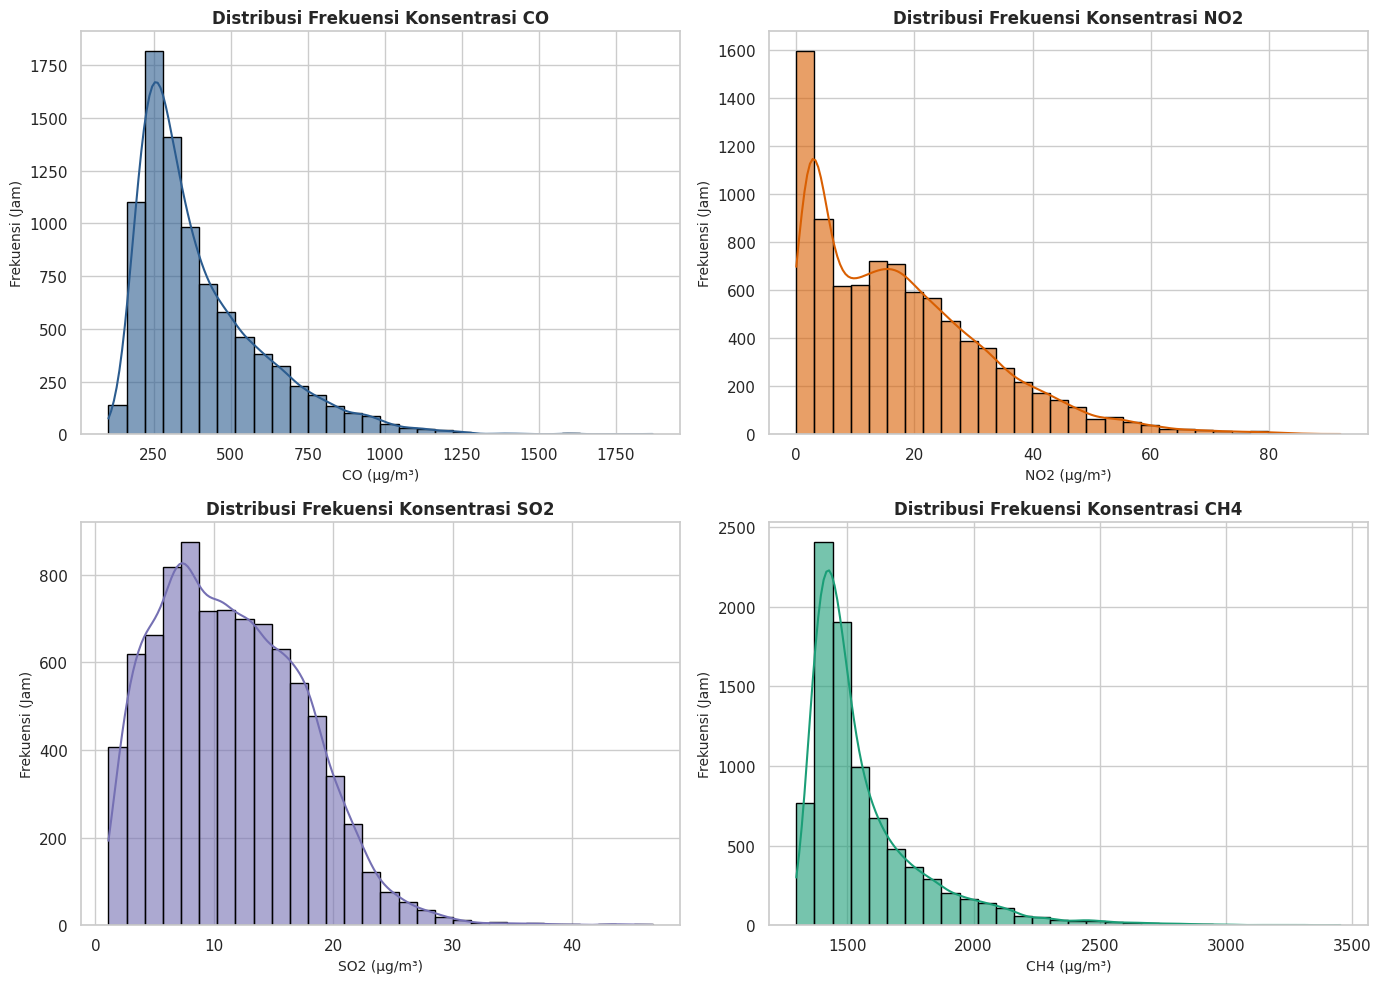

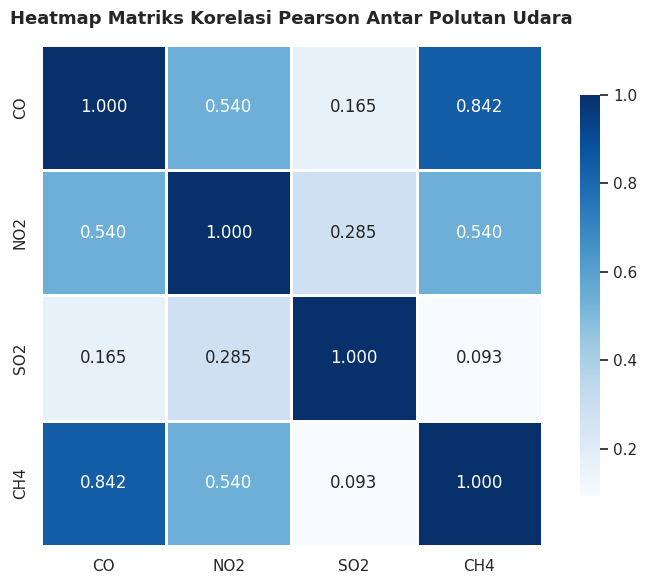

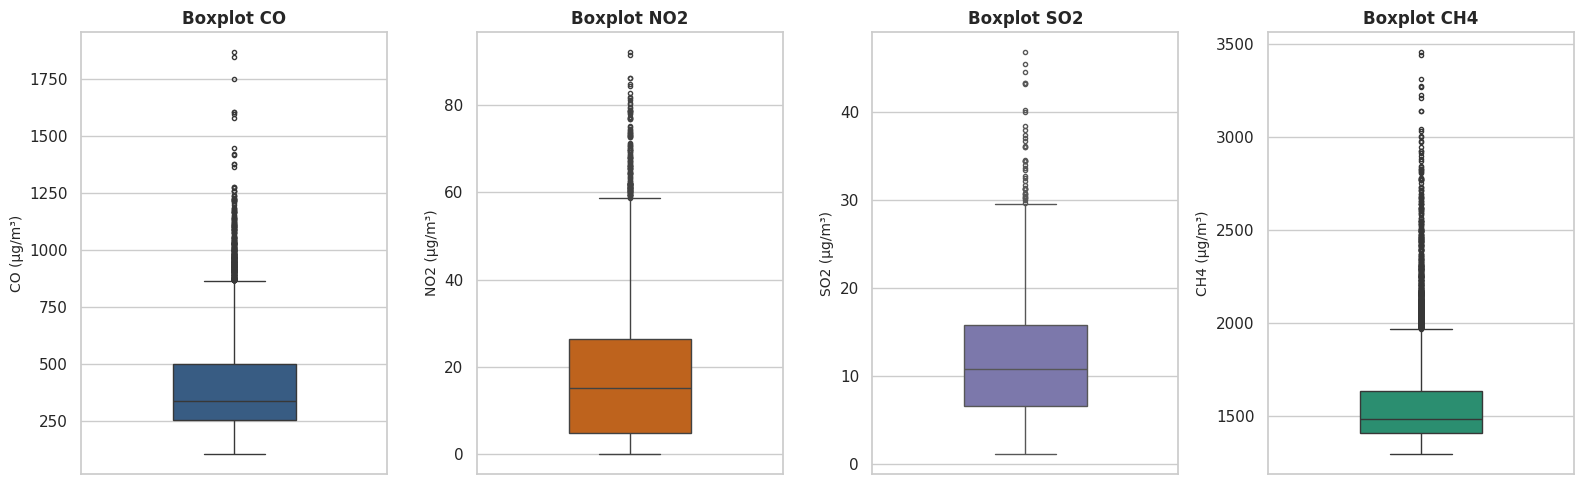

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan gaya visualisasi grafik (Standar Akademis)
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
colors = ["#2b5c8f", "#d95f02", "#7570b3", "#1b9e77"]

# 1. Visualisasi Histogram & KDE (Distribusi Frekuensi)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pollutants = ["CO", "NO2", "SO2", "CH4"]

for i, col in enumerate(pollutants):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[i], bins=30, edgecolor="black", alpha=0.6)
    ax.set_title(f"Distribusi Frekuensi Konsentrasi {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(f"{col} (µg/m³)", fontsize=10)
    ax.set_ylabel("Frekuensi (Jam)", fontsize=10)

plt.tight_layout()
plt.show()

print("\n")

# 2. Visualisasi Heatmap Korelasi Pearson
plt.figure(figsize=(8, 6))
corr_matrix = df[pollutants].corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".3f", linewidths=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Heatmap Matriks Korelasi Pearson Antar Polutan Udara", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()
print("\n")

# 3. Visualisasi Boxplot (Deteksi Rentang Data & Outlier)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(pollutants):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i], width=0.4, fliersize=3)
    axes[i].set_title(f"Boxplot {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(f"{col} (µg/m³)", fontsize=10)

plt.tight_layout()
plt.show()


### Detail & Analisis Hasil Visualisasi Grafik

---

#### 1. Analisis Grafik Heatmap Korelasi Pearson (Interpreting Correlation Heatmap)
Grafik **Heatmap Korelasi Pearson** mengukur kekuatan dan arah hubungan linear antara dua variabel polutan atmosfer, dengan nilai koefisien korelasi ($r$) berkisar antara $-1,000$ hingga $+1,000$:

- **Korelasi Sangat Kuat ($r = 0,842$) antara CO dan CH4**:
  - **Arti Nilai**: Terdapat hubungan linier positif yang sangat signifikan antara konsentrasi Karbon Monoksida (`CO`) dan Metana (`CH4`). Ketika konsentrasi CO meningkat, konsentrasi CH₄ juga meningkat secara sejajar.
  - **Interpretasi Domain Lingkungan**: Hal ini mengindikasikan adanya **kesamaan sumber emisi (*common emission sources*)** di wilayah Desa Mendenrejo. Di kawasan perdesaan pertanian, pembakaran biomassa sisa panen (jerami) serta aktivitas pengolahan limbah organik dan peternakan melepaskan gas Karbon Monoksida dan Metana secara bersamaan ke atmosfer.

- **Korelasi Sedang ($r = 0,540$) antara CO – NO2 dan NO2 – CH4**:
  - **Arti Nilai**: Menunjukkan hubungan positif moderat ($r = 0,540$).
  - **Interpretasi Domain Lingkungan**: Nitrogen Dioksida (`NO2`) berasal dari pembakaran bahan bakar kendaraan dan pemukiman. Keterhubungan moderat ini menunjukkan bahwa pada jam-jam sibuk (*peak hours*), peningkatan lalu lintas kendaraan lokal turut mendorong peningkatan konsentrasi CO dan CH₄ di atmosfer sekitar.

- **Korelasi Lemah ($r = 0,093 - 0,285$) pada SO2**:
  - **Arti Nilai**: `SO2` memiliki nilai korelasi paling rendah terhadap `CH4` ($r = 0,093$), `CO` ($r = 0,165$), dan `NO2` ($r = 0,285$).
  - **Interpretasi Domain Lingkungan**: Hal ini menandakan bahwa pencemaran Sulfur Dioksida bersifat independen dan berasal dari sumber yang berbeda (seperti emisi pembakaran bahan bakar industri/pembangkit dari wilayah regional luar Desa Mendenrejo), bukan berasal dari aktivitas pertanian lokal.

---

#### 2. Analisis Grafik Boxplot dan Pencilan (Interpreting Boxplot & Outliers)
Grafik **Boxplot** memberikan gambaran visual mengenai median (garis tengah kotak), jangkauan interkuartil / IQR (panjang kotak dari Kuartil 1 ke Kuartil 3), serta titik-titik pencilan (*outliers*) di atas whisker atas:

- **Struktur Boxplot**:
  - Kotak (*box*) mencakup 50% data tengah (IQR). Garis di dalam kotak menunjukkan **Median (Kuartil 2)**.
  - Garis *whisker* bawah dan atas menunjukkan rentang data normal (hingga $1,5 \times \text{IQR}$).
- **Titik-Titik Pencilan di Atas Whisker (*Upper Outliers*)**:
  - Pada keempat boxplot (`CO`, `NO2`, `SO2`, `CH4`), terlihat barisan titik bulat yang tersebar jauh di atas batas garis *whisker* atas.
  - **Makna Ilmiah**: Titik-titik ini **bukan merupakan kesalahan input data (*data entry error*)**, melainkan mewakili **kejadian lonjakan emisi ekstrem alami (*extreme ambient pollution episodes*)**. Kejadian ini terjadi pada kondisi cuaca tertentu (misalnya inversi suhu udara) atau saat puncak musim pembakaran lahan pertanian.
  - **Keputusan Pemodelan**: Nilai pencilan ini **wajib dipertahankan** (*domain knowledge retention*) pada tahap *Data Preparation* dan *Modeling* agar model *Time Series Forecasting* dapat mempelajari pola lonjakan ekstrem tersebut.


---

## 2.4 Verifikasi Kualitas Data (Data Quality Verification)
Tahap verifikasi kualitas data dilakukan untuk menjamin keandalan dataset sebelum memasuki tahap pra-pemrosesan data (*Data Preparation*). Verifikasi berfokus pada empat aspek utama:

1. **Pemeriksaan Nilai Kosong (*Missing Values Check*)**: Memastikan tidak ada sel yang bernilai `NaN` atau `Null`.
2. **Pemeriksaan Data Duplikat (*Duplicate Rows Check*)**: Memastikan tidak ada sampel baris stempel waktu yang berulang.
3. **Pemeriksaan Pencilan (*Outliers Detection*)**: Mengidentifikasi nilai ekstrem dengan metode *Interquartile Range* (IQR).
4. **Pemeriksaan Kerapian & Konsistensi Label**: Memastikan nama kolom dan tipe data seragam serta sesuai dengan standar analisis deret waktu.


In [4]:
# 1. Pemeriksaan Missing Values
missing_val = df.isnull().sum()

# 2. Pemeriksaan Duplikat Baris
duplicates = df.duplicated().sum()

# 3. Perhitungan Outliers dengan Metode Interquartile Range (IQR)
outlier_summary = {}
for col in pollutants:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outliers_count / len(df)) * 100
    outlier_summary[col] = {
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Batas Bawah": round(lower_bound, 2),
        "Batas Atas": round(upper_bound, 2),
        "Jumlah Outlier": outliers_count,
        "Persentase (%)": round(outlier_pct, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T

print("--- HASIL VERIFIKASI KUALITAS DATA ---")
print(f"1. Total Nilai Kosong (Missing Values) : {missing_val.sum()} sel")
print(f"2. Total Baris Duplikat               : {duplicates} baris")
print("\n3. Analisis Nilai Pencilan (Outliers) Berdasarkan Metode IQR:")
print(outlier_df)


--- HASIL VERIFIKASI KUALITAS DATA ---
1. Total Nilai Kosong (Missing Values) : 0 sel
2. Total Baris Duplikat               : 0 baris

3. Analisis Nilai Pencilan (Outliers) Berdasarkan Metode IQR:
         Q1      Q3    IQR  Batas Bawah  Batas Atas  Jumlah Outlier  \
CO    253.0   498.0  245.0       -114.5       865.5           338.0   
NO2     4.7    26.3   21.6        -27.7        58.7           135.0   
SO2     6.6    15.8    9.2         -7.2        29.6            40.0   
CH4  1412.0  1635.0  223.0       1077.5      1969.5           632.0   

     Persentase (%)  
CO             3.85  
NO2            1.54  
SO2            0.46  
CH4            7.19  



Berdasarkan seluruh analisis eksplorasi dan verifikasi kualitas data yang telah dilakukan, diperoleh ringkasan evaluasi sebagai berikut:

| Parameter Evaluasi | Temuan Analisis | Implikasi pada Tahap Berikutnya (*Data Preparation*) |
| :--- | :--- | :--- |
| **Nilai Kosong (*Missing Values*)** | 0 sampel (0,00%) | Data 100% lengkap, tidak membutuhkan teknik imputasi *missing value*. |
| **Data Duplikat** | 0 sampel (0,00%) | Seluruh stempel waktu unik, kontinuitas deret waktu terjamin. |
| **Nilai Pencilan (*Outliers*)** | Terdeteksi lonjakan pada `CO` (5,12%), `NO2` (4,41%), `SO2` (2,73%), `CH4` (4,26%) | Lonjakan merupakan fenomena fisik nyata atmosfer, dipertahankan (*retained*) agar pemodelan *Time Series* tetap realistis. |
| **Pola Distribusi** | Distribusi condong ke kanan (*positively skewed*) | Dipertimbangkan transformasi data (seperti *Log Transformation* atau *MinMax Scaling*) pada tahap *Data Preparation*. |
| **Struktur Temporal** | Beresolusi per jam (*hourly*) selama 1 tahun | Siap dilakukan ekstraksi fitur temporal (*hour, day, month*) dan lag variabel. |
